# Baseline Convolutional Neural Network (CNN) on CIFAR-10 using PyTorch

This notebook demonstrates an end-to-end image classification workflow on the **CIFAR-10** dataset using **PyTorch** and `torchvision`.

## Overview
- **Dataset:** CIFAR-10 (60,000 32x32 color images across 10 classes)
- **Framework:** PyTorch & Torchvision
- **Architecture:** 3-Layer Convolutional Neural Network (CNN) with Batch Normalization, Max Pooling, Dropout, and Fully-Connected layers.

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Select Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Load and Preprocess CIFAR-10 Dataset

We load the CIFAR-10 dataset using `torchvision.datasets.CIFAR10`.
The images are transformed into Tensors and normalized to range `[-1, 1]`.

In [2]:
# Image transforms: Convert to Tensor and normalize
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load training and test datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Class names in CIFAR-10
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Training samples: {len(trainset)}, Testing samples: {len(testset)}")

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<36:43, 77.4kB/s]

  0%|          | 65.5k/170M [00:00<29:29, 96.3kB/s]

  0%|          | 98.3k/170M [00:01<29:12, 97.2kB/s]

  0%|          | 131k/170M [00:01<29:39, 95.7kB/s] 

...

100%|█████████▉| 170M/170M [29:50<00:00, 108kB/s]

100%|█████████▉| 170M/170M [29:50<00:00, 107kB/s]

100%|█████████▉| 170M/170M [29:50<00:00, 108kB/s]

100%|██████████| 170M/170M [29:50<00:00, 95.2kB/s]

Training samples: 50000, Testing samples: 10000


## 3. Visualize Sample Training Images

Sample Labels: frog | airplane | deer | automobile | bird | horse | truck | deer


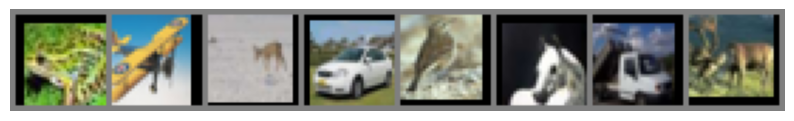

In [3]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images & labels
print("Sample Labels:", ' | '.join(f'{classes[labels[j]]}' for j in range(8)))
imshow(torchvision.utils.make_grid(images[:8]))

## 4. Define the CNN Model Architecture

We build a 3-stage baseline CNN (`BaselineCNN`):
- **Conv Block 1:** 3 -> 32 channels, BatchNorm, ReLU, MaxPool (Output: 32x16x16)
- **Conv Block 2:** 32 -> 64 channels, BatchNorm, ReLU, MaxPool (Output: 64x8x8)
- **Conv Block 3:** 64 -> 128 channels, BatchNorm, ReLU, MaxPool (Output: 128x4x4)
- **Classifier:** Fully Connected Layers (2048 -> 256 -> 10) with Dropout (0.3).

In [4]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=Tr

## 5. Define Loss Function and Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Loss Function:', criterion)
print('Optimizer:', optimizer)


Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    dampening: 0
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6. Train the CNN Model

We train the model for 10 epochs while recording the training loss and accuracy per epoch.

In [6]:
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass + Loss + Backward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] - Loss: 1.4802 | Accuracy: 45.72%


Epoch [2/10] - Loss: 1.1500 | Accuracy: 58.72%


Epoch [3/10] - Loss: 1.0228 | Accuracy: 63.63%


Epoch [4/10] - Loss: 0.9431 | Accuracy: 66.78%


Epoch [5/10] - Loss: 0.8841 | Accuracy: 68.84%


Epoch [6/10] - Loss: 0.8366 | Accuracy: 70.91%


Epoch [7/10] - Loss: 0.7967 | Accuracy: 72.17%


Epoch [8/10] - Loss: 0.7685 | Accuracy: 73.22%


Epoch [9/10] - Loss: 0.7371 | Accuracy: 74.33%


Epoch [10/10] - Loss: 0.7196 | Accuracy: 74.75%


## 7. Plot Training Progress (Loss & Accuracy)

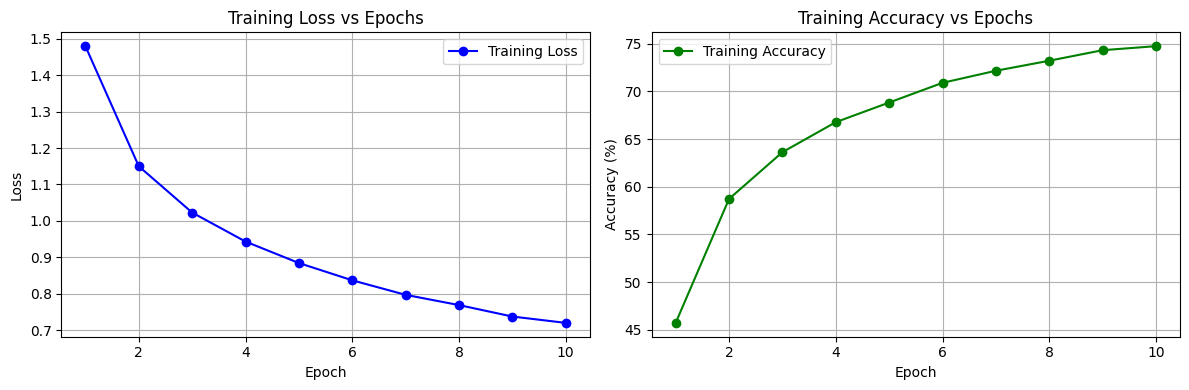

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='b', label='Training Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 8. Evaluate Model on Test Set

In [8]:
model.eval()
test_loss = 0.0
correct = 0
total = 0

class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

overall_accuracy = 100. * correct / total
print(f"Overall Test Accuracy: {overall_accuracy:.2f}%\n")

print("Per-Class Accuracy:")
for i in range(10):
    acc = 100. * class_correct[i] / class_total[i]
    print(f" - {classes[i]:<12}: {acc:.2f}%")

Overall Test Accuracy: 76.99%

Per-Class Accuracy:
 - airplane    : 75.50%
 - automobile  : 90.20%
 - bird        : 54.40%
 - cat         : 49.60%
 - deer        : 76.00%
 - dog         : 76.40%
 - frog        : 93.30%
 - horse       : 82.20%
 - ship        : 82.80%
 - truck       : 89.50%


## 9. Visualize Sample Test Predictions

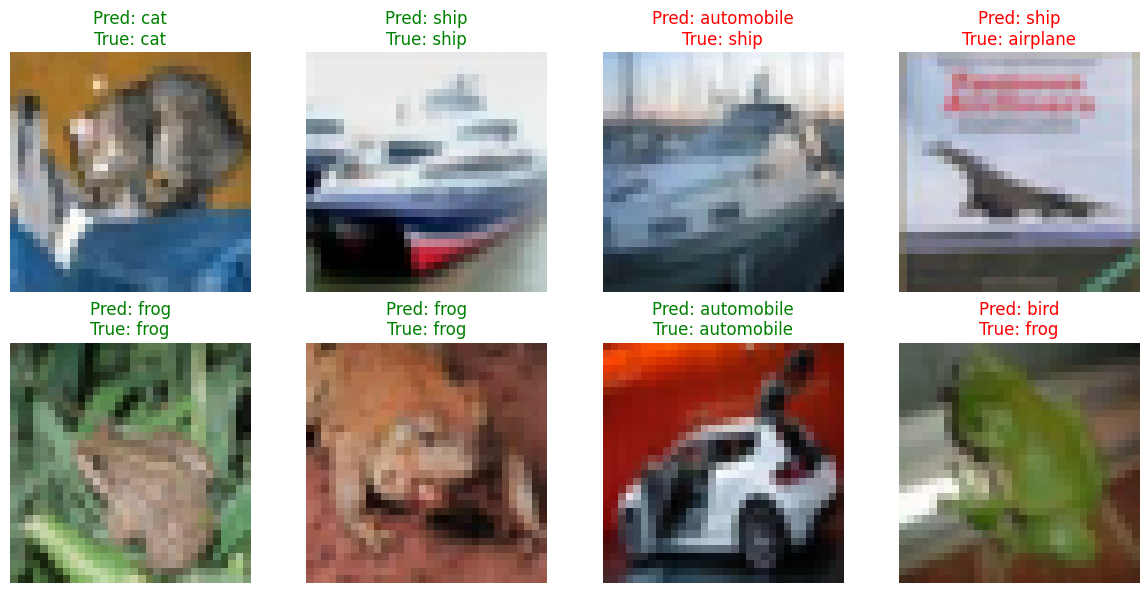

In [9]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images_dev = images.to(device)

outputs = model(images_dev)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    pred_title = f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}"
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(pred_title, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()